In [1]:
import pandas as pd
import numpy as np
import nrrd
import matplotlib.pyplot as plt
import os
from pathlib import Path

current = Path().resolve()

while not (current / ".git").exists():
    current = current.parent

PROJECT_ROOT = current

output_folder = PROJECT_ROOT / "extension/metypes/"

In the next cell you have to decide whether to include unassigned regions in the visualisation
- brain__with_unassigned_regions_me_types_composition.csv has unassigned regions included in the csv files


In [2]:
data_folder = PROJECT_ROOT / "extension/"
file = os.path.join(data_folder, "data/brain__with_unassigned_regions_me_types_composition.csv")

# file = 'brain_regions_me_types_composition.csv'

def load_me_data(file):
    df = pd.read_csv(file, header=[0, 1])
    df.columns = [f"{c0}|{c1}" for c0, c1 in df.columns]
    df = df.set_index("m-type|e-type")
    return df

me_data_df = load_me_data(file)


In [3]:
me_data_df.head()

,IN_DEND_0_AX_0|bAC,IN_DEND_0_AX_3|bAC,IN_DEND_0_AX_4|bAC,IN_DEND_0_AX_5|bAC,IN_DEND_0_AX_6|bAC,IN_DEND_0_AX_8|bAC,IN_DEND_0_AX_9|bAC,IN_DEND_1_AX_0|bAC,IN_DEND_1_AX_2|bAC,IN_DEND_1_AX_3|bAC,...,IN_DEND_6_AX_9|dSTUT,IN_DEND_7_AX_0|dSTUT,IN_DEND_7_AX_2|dSTUT,IN_DEND_7_AX_3|dSTUT,IN_DEND_7_AX_8|dSTUT,IN_DEND_8_AX_8|dSTUT,IN_DEND_9_AX_1|dSTUT,IN_DEND_9_AX_2|dSTUT,IN_DEND_9_AX_5|dSTUT,IN_DEND_9_AX_8|dSTUT
m-type|e-type,,,,,,,,,,,,,,,,,,,,,
AAA,70.449242,975.464976,196.029123,107.374364,219.967732,138.561698,283.032149,142.761830,149.290057,70.449242,...,49.439348,109.751091,388.660591,60.923194,68.018737,11.714693,14.186047,2.240268,35.851274,37.195722
ACAd1,0.552139,55.837603,193.193696,114.057692,14.570397,136.242688,1.930376,33.991054,67.684798,0.552139,...,25.008203,0.510173,4.546404,11.648074,5.622710,20.888031,23.041590,1.049859,0.000000,5.498831
ACAd23,6.038456,93.696665,945.982339,145.937467,75.870987,949.528317,19.084831,221.353239,434.166380,6.038456,...,27.189310,1.805363,37.214394,14.597905,51.716315,150.117788,39.591711,1.909610,0.000000,7.995749
ACAd5,17.444515,215.646037,209.701430,206.312044,107.602512,290.388972,55.884701,172.315602,319.815680,17.444515,...,20.831187,6.613080,27.502729,27.959385,41.723606,28.293837,31.184562,0.312694,0.000000,2.498040
ACAd6a,10.838466,527.528347,644.397412,85.810672,34.772651,653.315273,33.447949,397.848695,784.671171,10.838466,...,60.840542,1.736625,10.005915,12.827652,18.001872,99.345673,19.296173,0.972735,0.134379,21.993218


In [4]:
# Create 2 slices of the 3D brain (300 axial, 200 transversal)

CCFv3a, _ = nrrd.read(f'{data_folder}/annotation_25_2022_CCFv3a.nrrd')

# Replace all zeros in CCFv3a with np.nan
CCFv3a = np.where(CCFv3a == 0, np.nan, CCFv3a)

#Slice
zindex_200 = 200
xindex_300 = 300

zslice_200 = np.transpose(CCFv3a[:, :, zindex_200])
xslice_300 = CCFv3a[xindex_300, :, :]

In [5]:
# We load brain regon hierarchty: parcellation_to_parcellation_term_membership_extend

file_path = os.path.join(data_folder, "../densities_app/parcellation_to_parcellation_term_membership_extend.csv")
parcellation_annotation = pd.read_csv(file_path) 
#Get all ids i.e.  label_numbers and leaf regions i.e. 667 FRP23
ids = parcellation_annotation[parcellation_annotation['cluster_as_filename'].isin(me_data_df.index)][['label_numbers', 'cluster_as_filename']]

In [6]:
# # Generate df of ids with me-densities

# # Ensure matching data types (both should be strings)
# me_data_df.index = me_data_df.index.astype(str)
# ids['cluster_as_filename'] = ids['cluster_as_filename'].astype(str)

# # Reset index to make df.index a column
me_data_df.head()

,IN_DEND_0_AX_0|bAC,IN_DEND_0_AX_3|bAC,IN_DEND_0_AX_4|bAC,IN_DEND_0_AX_5|bAC,IN_DEND_0_AX_6|bAC,IN_DEND_0_AX_8|bAC,IN_DEND_0_AX_9|bAC,IN_DEND_1_AX_0|bAC,IN_DEND_1_AX_2|bAC,IN_DEND_1_AX_3|bAC,...,IN_DEND_6_AX_9|dSTUT,IN_DEND_7_AX_0|dSTUT,IN_DEND_7_AX_2|dSTUT,IN_DEND_7_AX_3|dSTUT,IN_DEND_7_AX_8|dSTUT,IN_DEND_8_AX_8|dSTUT,IN_DEND_9_AX_1|dSTUT,IN_DEND_9_AX_2|dSTUT,IN_DEND_9_AX_5|dSTUT,IN_DEND_9_AX_8|dSTUT
m-type|e-type,,,,,,,,,,,,,,,,,,,,,
AAA,70.449242,975.464976,196.029123,107.374364,219.967732,138.561698,283.032149,142.761830,149.290057,70.449242,...,49.439348,109.751091,388.660591,60.923194,68.018737,11.714693,14.186047,2.240268,35.851274,37.195722
ACAd1,0.552139,55.837603,193.193696,114.057692,14.570397,136.242688,1.930376,33.991054,67.684798,0.552139,...,25.008203,0.510173,4.546404,11.648074,5.622710,20.888031,23.041590,1.049859,0.000000,5.498831
ACAd23,6.038456,93.696665,945.982339,145.937467,75.870987,949.528317,19.084831,221.353239,434.166380,6.038456,...,27.189310,1.805363,37.214394,14.597905,51.716315,150.117788,39.591711,1.909610,0.000000,7.995749
ACAd5,17.444515,215.646037,209.701430,206.312044,107.602512,290.388972,55.884701,172.315602,319.815680,17.444515,...,20.831187,6.613080,27.502729,27.959385,41.723606,28.293837,31.184562,0.312694,0.000000,2.498040
ACAd6a,10.838466,527.528347,644.397412,85.810672,34.772651,653.315273,33.447949,397.848695,784.671171,10.838466,...,60.840542,1.736625,10.005915,12.827652,18.001872,99.345673,19.296173,0.972735,0.134379,21.993218


In [7]:
# Generate df of ids with me-densities

# Ensure matching data types (both should be strings)
me_data_df.index = me_data_df.index.astype(str)
ids['cluster_as_filename'] = ids['cluster_as_filename'].astype(str)

# Reset index to make df.index a column
me_data_df.reset_index(inplace=True)

# Merge based on df.index and ids.cluster_as_filename
merged_df = pd.merge(me_data_df, ids, left_on='m-type|e-type', right_on='cluster_as_filename')

# Optionally set the 'index' back as the index and clean up
merged_df.set_index('m-type|e-type', inplace=True)
merged_df.drop(columns='cluster_as_filename', inplace=True)

In [8]:
merged_df.sum()

IN_DEND_0_AX_0|bAC      3.924873e+04
IN_DEND_0_AX_3|bAC      8.715283e+05
IN_DEND_0_AX_4|bAC      9.399703e+05
IN_DEND_0_AX_5|bAC      1.912761e+05
IN_DEND_0_AX_6|bAC      1.615462e+05
                            ...     
IN_DEND_9_AX_1|dSTUT    3.397224e+04
IN_DEND_9_AX_2|dSTUT    4.475307e+04
IN_DEND_9_AX_5|dSTUT    3.098548e+04
IN_DEND_9_AX_8|dSTUT    4.988894e+04
label_numbers           4.781939e+10
Length: 459, dtype: float64

In [9]:
merged_df.columns[merged_df.columns.str.contains("PC_DEND_0_AX_8|cADpyr")]


Index(['PC_DEND_0_AX_8|cADpyr', 'PC_DEND_1_AX_7|cADpyr',
       'PC_DEND_2_AX_4|cADpyr', 'PC_DEND_2_AX_8|cADpyr',
       'PC_DEND_3_AX_0|cADpyr', 'PC_DEND_3_AX_4|cADpyr',
       'PC_DEND_3_AX_6|cADpyr', 'PC_DEND_3_AX_7|cADpyr',
       'PC_DEND_3_AX_8|cADpyr', 'PC_DEND_8_AX_4|cADpyr',
       'PC_DEND_8_AX_8|cADpyr'],
      dtype='object')

CPU times: user 75 ms, sys: 1.51 ms, total: 76.5 ms
Wall time: 75.9 ms


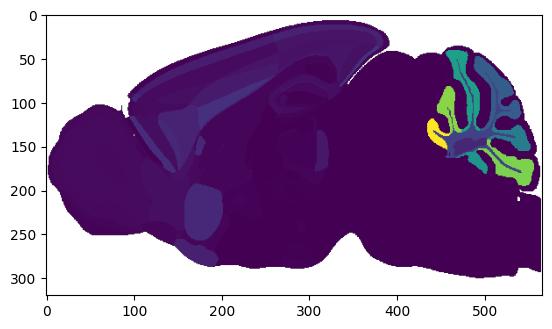

In [10]:
%%time

# Prepare the label mapping
me_type = 'PC_DEND_0_AX_8|cADpyr'
label_numbers = merged_df['label_numbers'].values
cluster_values = merged_df[me_type].values
label_to_cluster = dict(zip(label_numbers, cluster_values))

# Define the worker function
def process_CCFv3a(CCFv3a, label_to_cluster, label_numbers):

    new_CCFv3a = np.full_like(CCFv3a, np.nan)

    for label in label_numbers:
        new_CCFv3a[CCFv3a == label] = label_to_cluster[label]
        
    # Retain existing np.nan values from the original CCFv3a
    nan_mask = np.isnan(CCFv3a)
    new_CCFv3a[nan_mask] = np.nan
    
    # Set 0 where values have not been populated
    new_CCFv3a[(~nan_mask) & (new_CCFv3a == np.nan)] = 0
    
    return new_CCFv3a


new_CCFv3a = process_CCFv3a(zslice_200, label_to_cluster, label_numbers)
plt.imshow(new_CCFv3a);

In [11]:
me_type_names = list(me_data_df.columns[1:])

In [12]:
%%time

label_numbers = merged_df['label_numbers'].values

for me_type in me_type_names:
    cluster_values = merged_df[me_type].values
    label_to_cluster = dict(zip(label_numbers, cluster_values))
    me_transv = process_CCFv3a(zslice_200, label_to_cluster, label_numbers)
    np.save(os.path.join(output_folder, f"transversal/{me_type}_transv_200.npy"), me_transv)
    me_axial = process_CCFv3a(xslice_300, label_to_cluster, label_numbers)
    np.save(os.path.join(output_folder, f"axial/{me_type}_axial_300.npy"), me_axial)
    # print(f"{me_type} saved.")

CPU times: user 4min 15s, sys: 654 ms, total: 4min 16s
Wall time: 4min 16s


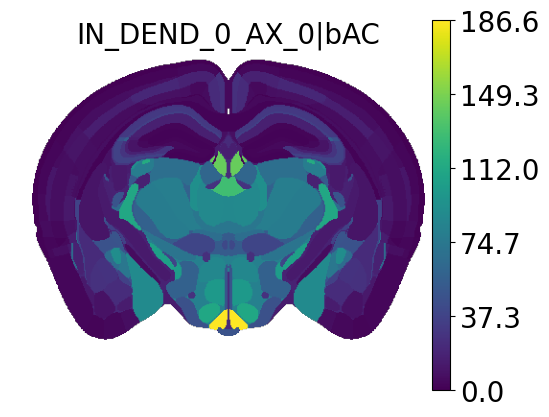

In [13]:
# Choose input folder
input_folder = os.path.join(output_folder, "axial")
# input_folder = os.path.join(output_folder, "transversal")

# Pick one file
files = sorted(f for f in os.listdir(input_folder) if f.endswith(".npy"))
file = files[0]   # or any index you want

# Load array
arr = np.load(os.path.join(input_folder, file))

fig, ax = plt.subplots()

im = ax.imshow(
    arr,
    cmap="viridis",
    vmin=0,
    vmax=np.nanmax(arr)
)

cbar = fig.colorbar(im, ax=ax, pad=-0.03)
cbar.set_ticks(np.linspace(0, np.nanmax(arr), 6))
cbar.ax.tick_params(labelsize=20)
plt.title(file[:-14], fontsize=20)
ax.axis("off")
# plt.savefig(f"../extension/fig_me_ax/{file[:-14]}.png", bbox_inches='tight', pad_inches=0)
plt.show()

In [14]:
def plot_single_npy(
    output_folder,
    file,                       # <-- pass file explicitly
    orientation="axial",        # "axial" or "transversal"
    save_dir="../extension/fig_me_ax",
    cmap="viridis",
    title_fontsize=20,
    tick_fontsize=20
):
    """
    Load a single .npy file, plot it with its own colorbar,
    and save the figure as a PNG.
    """

    # Choose input folder
    input_folder = os.path.join(output_folder, orientation)

    # Load array
    arr = np.load(os.path.join(input_folder, file))
    vmax = np.nanmax(arr)

    # Create figure
    fig, ax = plt.subplots()

    im = ax.imshow(
        arr,
        cmap=cmap,
        vmin=0,
        vmax=vmax
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=-0.03)
    cbar.set_ticks(np.linspace(0, vmax, 6))
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Title and layout
    ax.set_title(file[:-14], fontsize=title_fontsize)
    ax.axis("off")

    # Ensure save directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Save figure
    save_path = os.path.join(save_dir, f"{file[:-14]}.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

    return save_path

In [16]:
import os
from PIL import Image
import math
import numpy as np
import matplotlib.pyplot as plt

def create_composite_from_pngs(save_dir, output_path):
    """
    Open all PNGs in save_dir, pad them to the largest width/height with transparency,
    arrange them in a nearly square grid, and save as one composite image.
    """
    # List all PNG files
    files = sorted(f for f in os.listdir(save_dir) if f.endswith(".png"))
    if not files:
        raise ValueError("No PNG files found in save_dir.")

    # Open all images
    images = [Image.open(os.path.join(save_dir, f)).convert("RGBA") for f in files]

    # Find max width and height
    max_w = max(img.width for img in images)
    max_h = max(img.height for img in images)

    # Pad each image to max size with transparency
    images_padded = []
    for img in images:
        canvas = Image.new("RGBA", (max_w, max_h), (0, 0, 0, 0))  # transparent background
        canvas.paste(img, (0, 0))  # top-left aligned
        images_padded.append(canvas)

    # Compute grid size (near-square)
    n = len(images_padded)
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    # Pad remaining slots with transparent images if needed
    pad = rows * cols - n
    if pad > 0:
        transparent = Image.new("RGBA", (max_w, max_h), (0, 0, 0, 0))
        images_padded.extend([transparent] * pad)

    # Build rows
    row_images = []
    for r in range(rows):
        row_imgs = images_padded[r * cols:(r + 1) * cols]
        row_combined = np.hstack([np.array(img) for img in row_imgs])
        row_images.append(row_combined)

    # Stack all rows vertically
    mosaic_array = np.vstack(row_images)

    # Convert back to PIL Image
    mosaic = Image.fromarray(mosaic_array)

    # Save
    mosaic.save(output_path)
    print(f"Composite saved: {output_path}")

    # Optional: display
    plt.figure(figsize=(cols * 2, rows * 2))
    plt.imshow(mosaic)
    plt.axis("off")
    plt.show()